    Time Spent (Minutes)  Purchase
0                      2         0
1                      3         0
2                      4         0
3                      5         0
4                      6         0
5                      7         0
6                      8         0
7                      9         0
8                     10         0
9                     11         0
10                    12         1
11                    13         1
12                    14         1
13                    15         1
14                    16         1
15                    17         1
16                    18         1
17                    19         1
18                    20         1
19                    21         1
20                    22         1
21                    23         1
22                    24         1
23                    25         1
24                    26         1
25                    27         1
26                    28         1
27                  

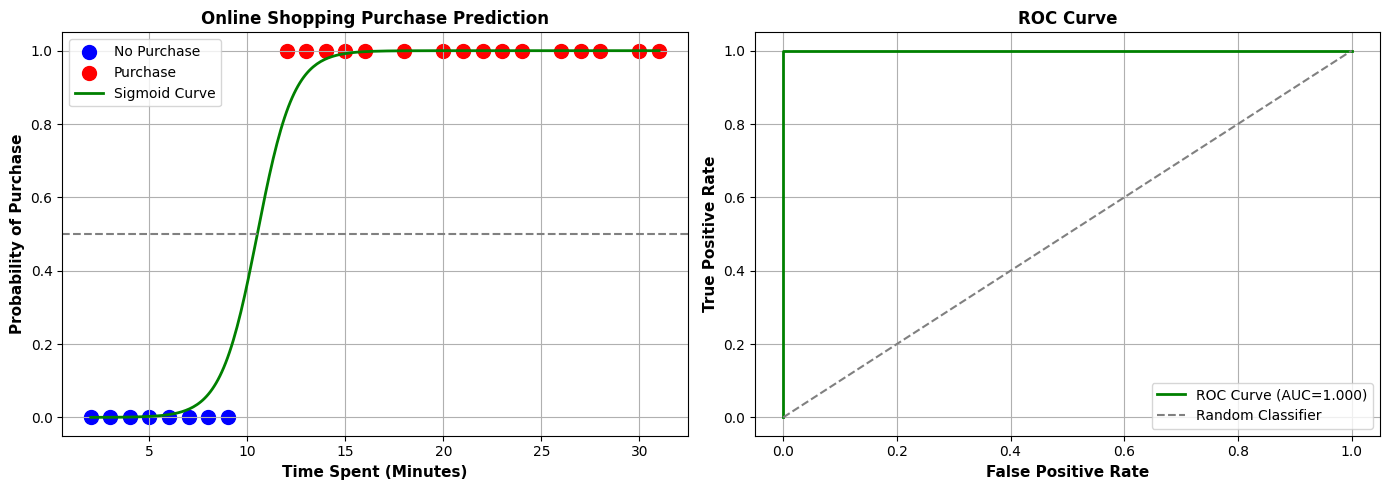

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
time_spent = np.array([2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]).reshape(-1,1)
purchase = np.array([0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
df = pd.DataFrame({
    "Time Spent (Minutes)": time_spent.flatten(),
    "Purchase": purchase})
print(df)

X_train, X_test, y_train, y_test = train_test_split(time_spent,purchase,test_size=0.2,random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

auc = roc_auc_score(y_test, y_pred_proba[:,1])
fig, axes = plt.subplots(1,2,figsize=(14,5))
X_range = np.linspace(time_spent.min(),time_spent.max(),300).reshape(-1,1)
y_prob = model.predict_proba(X_range)[:,1]

axes[0].scatter(X_train[y_train==0],y_train[y_train==0],color='blue',s=100,label='No Purchase')
axes[0].scatter(X_train[y_train==1],y_train[y_train==1],color='red',s=100,label='Purchase')
axes[0].plot(X_range,y_prob,color='green',linewidth=2,label='Sigmoid Curve')
axes[0].axhline(y=0.5,color='gray',linestyle='--')
axes[0].set_xlabel("Time Spent (Minutes)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Probability of Purchase", fontsize=11, fontweight='bold')
axes[0].set_title("Online Shopping Purchase Prediction", fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True)

fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:,1])
axes[1].plot(fpr,tpr,color='green',linewidth=2,label=f'ROC Curve (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],color='gray',linestyle='--',label='Random Classifier')
axes[1].set_xlabel("False Positive Rate", fontsize=11, fontweight='bold')
axes[1].set_ylabel("True Positive Rate", fontsize=11, fontweight='bold')
axes[1].set_title("ROC Curve", fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()